In [1]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu') # for gpu usage

Using device: cuda


## Loading MNIST Dataset

In [2]:
# Transform: Convert images to tensors and normalize between 0 and 1
transform = transforms.Compose([
    transforms.ToTensor()
])

# Download MNIST dataset
train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset  = datasets.MNIST(root='./data', train=False, download=True, transform=transform)

# DataLoaders
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False)

print(f'Training samples : {len(train_dataset)}')
print(f'Test samples     : {len(test_dataset)}')

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.62MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 133kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.26MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 7.20MB/s]

Training samples : 60000
Test samples     : 10000


## Visualizing Sample Images

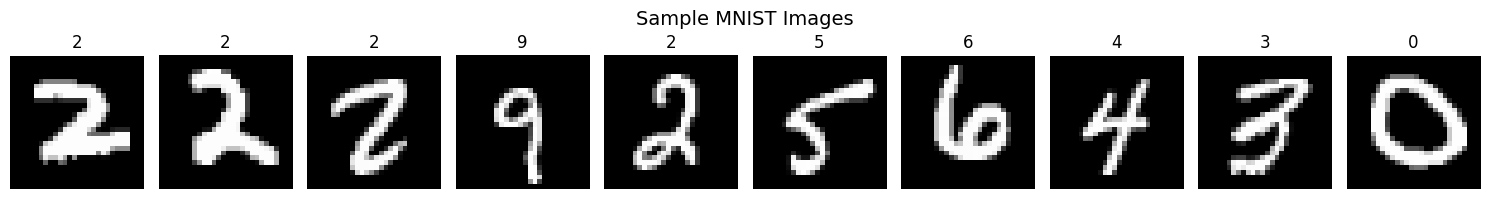

In [3]:
# Show some sample images from the dataset
examples = iter(train_loader)
images, labels = next(examples)

fig, axes = plt.subplots(1, 10, figsize=(15, 2))
for i in range(10):
    axes[i].imshow(images[i].squeeze(), cmap='gray')
    axes[i].set_title(str(labels[i].item()))
    axes[i].axis('off')
plt.suptitle('Sample MNIST Images', fontsize=14)
plt.tight_layout()
plt.show()

## Adding Noise to Images

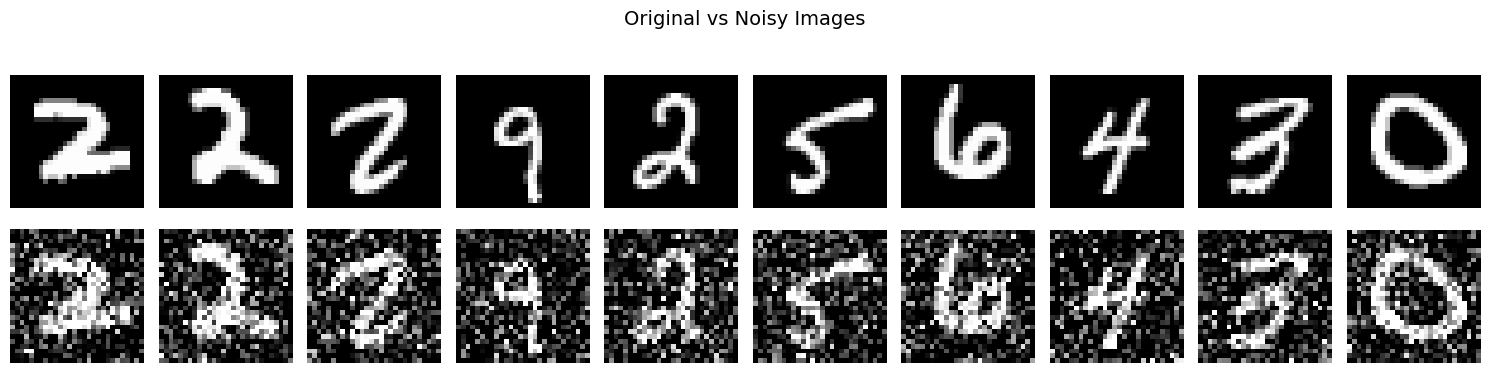

In [4]:
def add_noise(images, noise_factor=0.4):
    """
    Adds Gaussian noise to a batch of images.
    noise_factor controls the strength of noise.
    """
    noisy = images + noise_factor * torch.randn_like(images)
    # Clip values to stay in [0, 1] range
    noisy = torch.clamp(noisy, 0., 1.)
    return noisy

# Visualize original vs noisy images
sample_images = images[:10]
noisy_images  = add_noise(sample_images)

fig, axes = plt.subplots(2, 10, figsize=(15, 4))
for i in range(10):
    axes[0, i].imshow(sample_images[i].squeeze(), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].imshow(noisy_images[i].squeeze(), cmap='gray')
    axes[1, i].axis('off')

axes[0, 0].set_ylabel('Original', fontsize=12)
axes[1, 0].set_ylabel('Noisy', fontsize=12)
plt.suptitle('Original vs Noisy Images', fontsize=14)
plt.tight_layout()
plt.show()

## Building Autoencoder Model

In [5]:
class DenoisingAutoencoder(nn.Module):
    def __init__(self):
        super(DenoisingAutoencoder, self).__init__()

        # Encoder
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU()
        )

        # Decoder
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()  # Output in [0, 1] to match normalized image values
        )

    def forward(self, x):
        # Flatten the image: (batch, 1, 28, 28) -> (batch, 784)
        x = x.view(x.size(0), -1)
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

# Initialize model
model = DenoisingAutoencoder().to(device)
print(model)
print(f'\nTotal parameters: {sum(p.numel() for p in model.parameters()):,}')

DenoisingAutoencoder(
  (encoder): Sequential(
    (0): Linear(in_features=784, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=64, bias=True)
    (5): ReLU()
  )
  (decoder): Sequential(
    (0): Linear(in_features=64, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=784, bias=True)
    (5): Sigmoid()
  )
)

Total parameters: 484,944


## Creating Loss Function and Optimizer

In [6]:
# Binary Cross Entropy Loss is suitable for pixel-wise reconstruction (values in [0,1])
criterion = nn.BCELoss()

# Adam optimizer
optimizer = optim.Adam(model.parameters(), lr=1e-3)

print('Loss function : Binary Cross Entropy')
print('Optimizer     : Adam (lr=0.001)')

Loss function : Binary Cross Entropy
Optimizer     : Adam (lr=0.001)


## Autoencoder training

In [7]:
EPOCHS = 20
NOISE_FACTOR = 0.4
train_losses = []

for epoch in range(EPOCHS):
    model.train()
    running_loss = 0.0

    for images, _ in train_loader:
        images = images.to(device)

        # Add noise to input images
        noisy_images = add_noise(images, NOISE_FACTOR).to(device)

        # Forward pass: feed noisy images, target is clean images
        outputs = model(noisy_images)
        targets = images.view(images.size(0), -1)  # Flatten clean images

        loss = criterion(outputs, targets)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)
    train_losses.append(avg_loss)

    if (epoch + 1) % 5 == 0 or epoch == 0:
        print(f'Epoch [{epoch+1:02d}/{EPOCHS}] | Loss: {avg_loss:.4f}')

print('\nTraining Complete!')

Epoch [01/20] | Loss: 0.2563
Epoch [05/20] | Loss: 0.1344
Epoch [10/20] | Loss: 0.1159
Epoch [15/20] | Loss: 0.1086
Epoch [20/20] | Loss: 0.1046

Training Complete!


## Plotting Train Loss

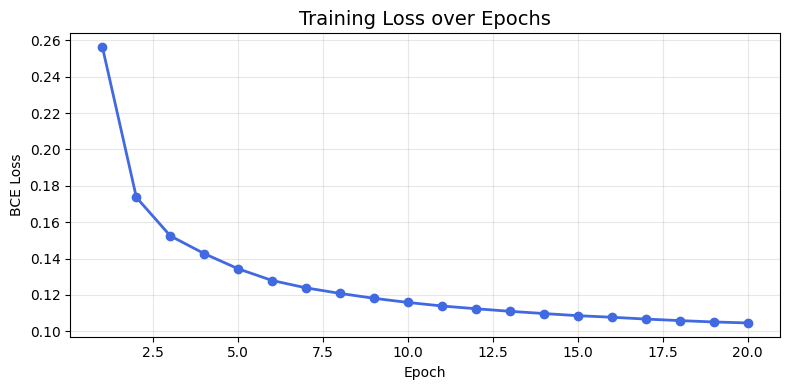

In [8]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, EPOCHS+1), train_losses, marker='o', color='royalblue', linewidth=2)
plt.title('Training Loss over Epochs', fontsize=14)
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Visualize Denoising Results

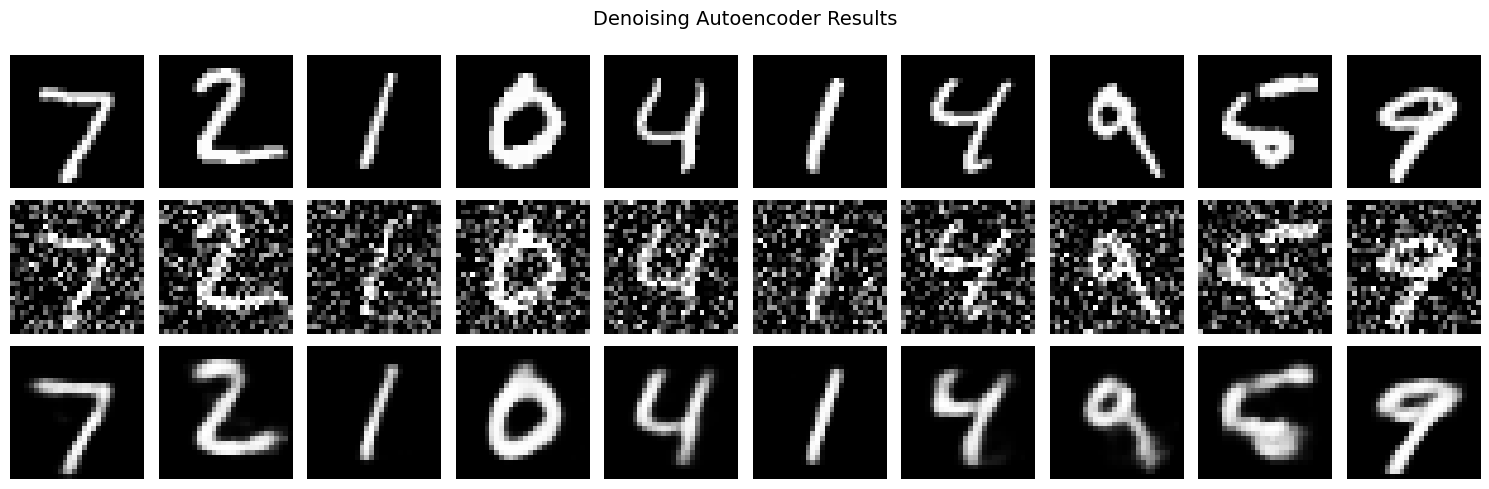

In [9]:
model.eval()

with torch.no_grad():
    test_images, _ = next(iter(test_loader))
    test_images    = test_images.to(device)
    noisy_test     = add_noise(test_images, NOISE_FACTOR).to(device)
    reconstructed  = model(noisy_test)
    reconstructed  = reconstructed.view(-1, 1, 28, 28)  # Reshape back to image format

# Plot: Original | Noisy | Denoised
n = 10
fig, axes = plt.subplots(3, n, figsize=(15, 5))

for i in range(n):
    # Original
    axes[0, i].imshow(test_images[i].cpu().squeeze(), cmap='gray')
    axes[0, i].axis('off')

    # Noisy
    axes[1, i].imshow(noisy_test[i].cpu().squeeze(), cmap='gray')
    axes[1, i].axis('off')

    # Denoised
    axes[2, i].imshow(reconstructed[i].cpu().squeeze(), cmap='gray')
    axes[2, i].axis('off')

axes[0, 0].set_ylabel('Original',  fontsize=12)
axes[1, 0].set_ylabel('Noisy',     fontsize=12)
axes[2, 0].set_ylabel('Denoised',  fontsize=12)
plt.suptitle('Denoising Autoencoder Results', fontsize=14)
plt.tight_layout()
plt.show()

## Calculating Test Loss

In [10]:
model.eval()
test_loss = 0.0

with torch.no_grad():
    for images, _ in test_loader:
        images       = images.to(device)
        noisy_images = add_noise(images, NOISE_FACTOR).to(device)
        outputs      = model(noisy_images)
        targets      = images.view(images.size(0), -1)
        loss         = criterion(outputs, targets)
        test_loss   += loss.item()

avg_test_loss = test_loss / len(test_loader)
print(f'Average Test Loss: {avg_test_loss:.4f}')

Average Test Loss: 0.1036
